# Классификация: SI > медианного значения

**Задача:** бинарная классификация — превышает ли IC50 медианное значение по выборке.

- **Класс 0:** IC50 ≤ медиана (соединение слабо активное)
- **Класс 1:** IC50 > медиана (соединение высокоактивное)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, accuracy_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost не установлен, пропускаем')

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print('LightGBM не установлен, пропускаем')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
SEED = 42

## 1. Загрузка и подготовка данных

In [2]:
TARGET_COL = 'SI'   # исходная переменная для порога
LABEL_COL  = 'y_SI_gt_median'
TASK_NAME  = 'SI_gt_median'
ALL_TARGETS = ['IC50, mM', 'CC50, mM', 'SI']

try:
    df = pd.read_csv('data_clean.csv')
    print('Загружен data_clean.csv')
except FileNotFoundError:
    df = pd.read_csv('Данные_для_курсовои_Классическое_МО.csv', sep=';', decimal=',')
    df = df.drop(columns=['Unnamed: 0'], errors='ignore')
    print('Загружен исходный CSV')

# Формируем метку если её нет
if LABEL_COL not in df.columns:
    median_val = df[TARGET_COL].median()
    df[LABEL_COL] = (df[TARGET_COL] > median_val).astype(int)
    print(f'Медиана {TARGET_COL} = {median_val:.4f}')

drop_cols = ALL_TARGETS + [c for c in df.columns if c.startswith('y_')]
FEATURE_COLS = [c for c in df.columns if c not in drop_cols]

X = df[FEATURE_COLS].copy()
y = df[LABEL_COL].copy()

print(f'Размер X: {X.shape}')
print(f'Баланс классов: класс 0 = {(y==0).sum()}, класс 1 = {(y==1).sum()}')

Загружен data_clean.csv
Размер X: (1001, 192)
Баланс классов: класс 0 = 501, класс 1 = 500


## 2. Базовое сравнение классификаторов (StratifiedKFold=5)

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

base_models = {
    'Logistic Regression':    LogisticRegression(max_iter=1000, random_state=SEED),
    'KNN':                    KNeighborsClassifier(n_neighbors=7),
    'Naive Bayes':            GaussianNB(),
    'SVM (RBF)':              SVC(kernel='rbf', probability=True, random_state=SEED),
    'Random Forest':          RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Extra Trees':            ExtraTreesClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting':      GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

if HAS_XGB:
    base_models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=SEED,
                                            eval_metric='logloss', verbosity=0)
if HAS_LGB:
    base_models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=SEED, verbose=-1)

results = []

for name, model in base_models.items():
    pipe = Pipeline([
        ('var_thresh', VarianceThreshold(threshold=0.0)),
        ('imputer',   SimpleImputer(strategy='median')),
        ('scaler',     RobustScaler()),
        ('model',      model)
    ])
    acc  = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    f1   = cross_val_score(pipe, X, y, cv=cv, scoring='f1', n_jobs=-1)
    roc  = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    results.append({
        'Model':    name,
        'Accuracy': acc.mean(),
        'F1':       f1.mean(),
        'ROC-AUC':  roc.mean(),
        'F1 std':   f1.std()
    })
    print(f'{name:25s} | Acc={acc.mean():.4f} | F1={f1.mean():.4f}±{f1.std():.4f} | AUC={roc.mean():.4f}')

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n=== Итог (по ROC-AUC) ===')
print(results_df.round(4).to_string(index=False))

Logistic Regression       | Acc=0.6194 | F1=0.6203±0.0330 | AUC=0.6769
KNN                       | Acc=0.6593 | F1=0.6609±0.0188 | AUC=0.7216
Naive Bayes               | Acc=0.5165 | F1=0.6481±0.0351 | AUC=0.6168
SVM (RBF)                 | Acc=0.5035 | F1=0.6680±0.0039 | AUC=0.6032
Random Forest             | Acc=0.6563 | F1=0.6519±0.0397 | AUC=0.7197
Extra Trees               | Acc=0.6573 | F1=0.6518±0.0376 | AUC=0.7011
Gradient Boosting         | Acc=0.6543 | F1=0.6526±0.0312 | AUC=0.7045
XGBoost                   | Acc=0.6414 | F1=0.6395±0.0474 | AUC=0.6969
LightGBM                  | Acc=0.6633 | F1=0.6586±0.0387 | AUC=0.7181

=== Итог (по ROC-AUC) ===
              Model  Accuracy     F1  ROC-AUC  F1 std
                KNN    0.6593 0.6609   0.7216  0.0188
      Random Forest    0.6563 0.6519   0.7197  0.0397
           LightGBM    0.6633 0.6586   0.7181  0.0387
  Gradient Boosting    0.6543 0.6526   0.7045  0.0312
        Extra Trees    0.6573 0.6518   0.7011  0.0376
          

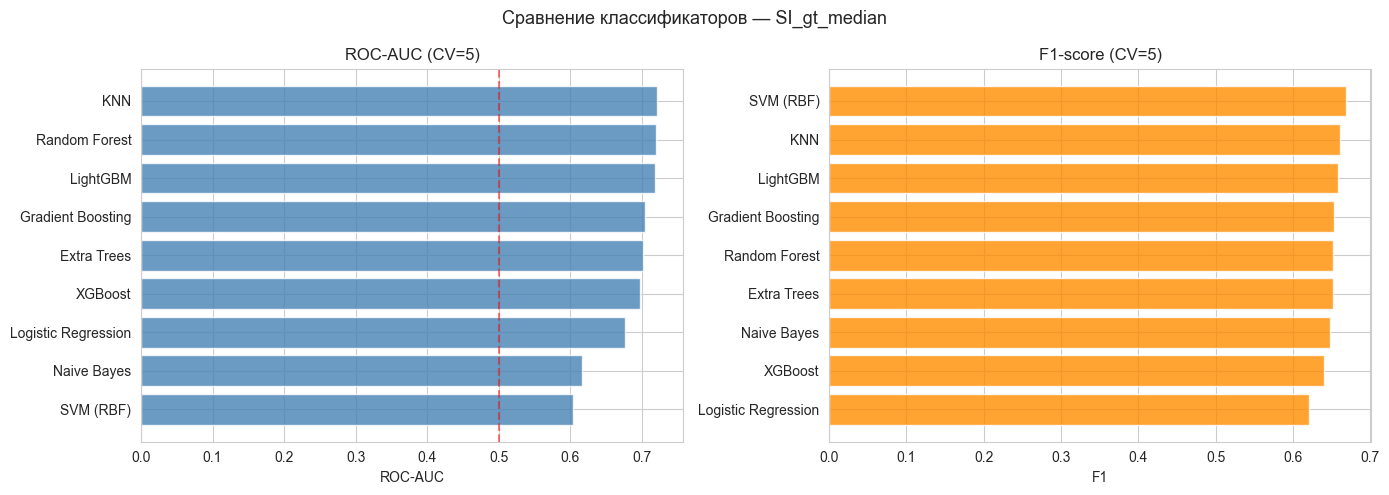

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rs = results_df.sort_values('ROC-AUC')
axes[0].barh(rs['Model'], rs['ROC-AUC'], color='steelblue', alpha=0.8)
axes[0].set_title('ROC-AUC (CV=5)')
axes[0].set_xlabel('ROC-AUC')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5)

rs2 = results_df.sort_values('F1')
axes[1].barh(rs2['Model'], rs2['F1'], color='darkorange', alpha=0.8)
axes[1].set_title('F1-score (CV=5)')
axes[1].set_xlabel('F1')

plt.suptitle(f'Сравнение классификаторов — {TASK_NAME}', fontsize=13)
plt.tight_layout()
plt.savefig(f'{TASK_NAME}_baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Подбор гиперпараметров для лучших моделей

In [5]:
# Logistic Regression — GridSearchCV
param_grid_lr = {
    'model__C':       [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'model__penalty': ['l1', 'l2'],
    'model__solver':  ['liblinear']
}

pipe_lr = Pipeline([
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('imputer',   SimpleImputer(strategy='median')),
    ('scaler',     RobustScaler()),
    ('model',      LogisticRegression(max_iter=1000, random_state=SEED))
])

gs_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1)
gs_lr.fit(X, y)
print(f'Logistic Regression — лучшие параметры: {gs_lr.best_params_}')
print(f'Logistic Regression — лучший AUC: {gs_lr.best_score_:.4f}')

Logistic Regression — лучшие параметры: {'model__C': 1.0, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
Logistic Regression — лучший AUC: 0.6965


In [6]:
# Random Forest — RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    'model__n_estimators':      randint(50, 300),
    'model__max_depth':         [None, 5, 10, 15, 20],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf':  randint(1, 10),
    'model__max_features':      ['sqrt', 'log2', 0.5]
}

pipe_rf = Pipeline([
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('imputer',   SimpleImputer(strategy='median')),
    ('scaler',     RobustScaler()),
    ('model',      RandomForestClassifier(random_state=SEED))
])

rs_rf = RandomizedSearchCV(
    pipe_rf, param_dist_rf,
    n_iter=30, cv=cv, scoring='roc_auc',
    random_state=SEED, n_jobs=-1
)
rs_rf.fit(X, y)
print(f'Random Forest — лучшие параметры:')
print(rs_rf.best_params_)
print(f'Random Forest — лучший AUC: {rs_rf.best_score_:.4f}')

Random Forest — лучшие параметры:
{'model__max_depth': 15, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 8, 'model__min_samples_split': 17, 'model__n_estimators': 286}
Random Forest — лучший AUC: 0.7351


In [7]:
# Gradient Boosting — RandomizedSearchCV
from scipy.stats import uniform

param_dist_gb = {
    'model__n_estimators':      randint(50, 400),
    'model__max_depth':         randint(2, 8),
    'model__learning_rate':     uniform(0.01, 0.29),
    'model__subsample':         uniform(0.6, 0.4),
    'model__min_samples_split': randint(2, 20)
}

pipe_gb = Pipeline([
    ('var_thresh', VarianceThreshold(threshold=0.0)),
    ('imputer',   SimpleImputer(strategy='median')),
    ('scaler',     RobustScaler()),
    ('model',      GradientBoostingClassifier(random_state=SEED))
])

rs_gb = RandomizedSearchCV(
    pipe_gb, param_dist_gb,
    n_iter=30, cv=cv, scoring='roc_auc',
    random_state=SEED, n_jobs=-1
)
rs_gb.fit(X, y)
print(f'Gradient Boosting — лучшие параметры:')
print(rs_gb.best_params_)
print(f'Gradient Boosting — лучший AUC: {rs_gb.best_score_:.4f}')

Gradient Boosting — лучшие параметры:
{'model__learning_rate': np.float64(0.014630213143862116), 'model__max_depth': 3, 'model__min_samples_split': 16, 'model__n_estimators': 313, 'model__subsample': np.float64(0.6137554084460873)}
Gradient Boosting — лучший AUC: 0.7260


## 4. ROC-кривые лучших моделей

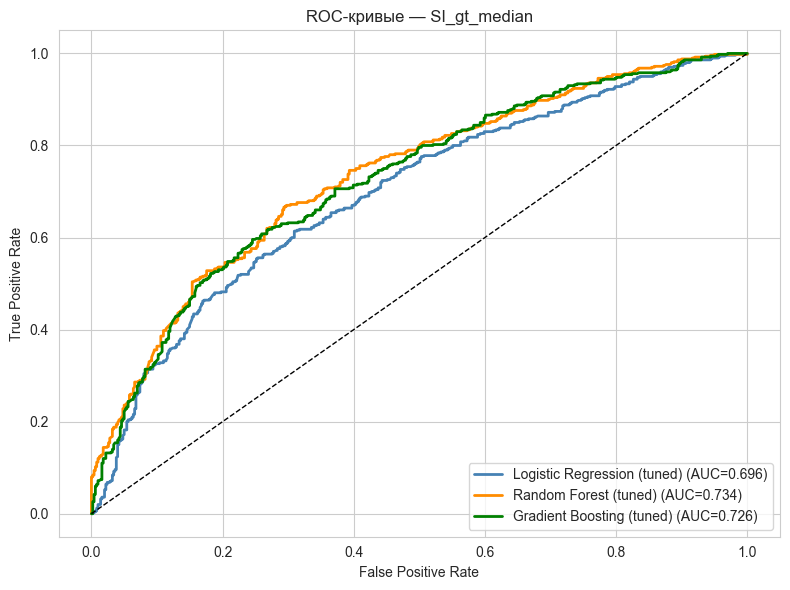

In [8]:
tuned_models = {
    'Logistic Regression (tuned)':  gs_lr.best_estimator_,
    'Random Forest (tuned)':        rs_rf.best_estimator_,
    'Gradient Boosting (tuned)':    rs_gb.best_estimator_,
}

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'green']

for (name, model), color in zip(tuned_models.items(), colors):
    y_prob = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})', lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC-кривые — {TASK_NAME}')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{TASK_NAME}_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Матрица ошибок лучшей модели

Лучшая модель: Random Forest (tuned) (AUC=0.7342)


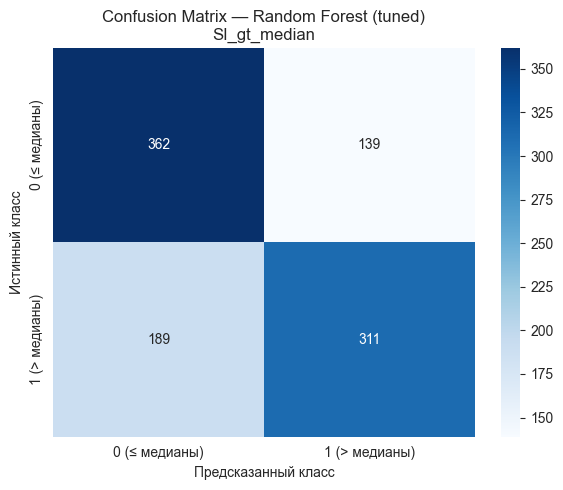


Classification Report:
              precision    recall  f1-score   support

   ≤ медианы       0.66      0.72      0.69       501
   > медианы       0.69      0.62      0.65       500

    accuracy                           0.67      1001
   macro avg       0.67      0.67      0.67      1001
weighted avg       0.67      0.67      0.67      1001



In [9]:
# Определяем лучшую по AUC
auc_scores = {}
for name, model in tuned_models.items():
    y_prob = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    auc_scores[name] = roc_auc_score(y, y_prob)

best_name = max(auc_scores, key=auc_scores.get)
best_model = tuned_models[best_name]
print(f'Лучшая модель: {best_name} (AUC={auc_scores[best_name]:.4f})')

y_pred = cross_val_predict(best_model, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0 (≤ медианы)', '1 (> медианы)'],
            yticklabels=['0 (≤ медианы)', '1 (> медианы)'])
plt.title(f'Confusion Matrix — {best_name}\n{TASK_NAME}')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.savefig(f'{TASK_NAME}_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y, y_pred, target_names=['≤ медианы', '> медианы']))

## 6. Важность признаков

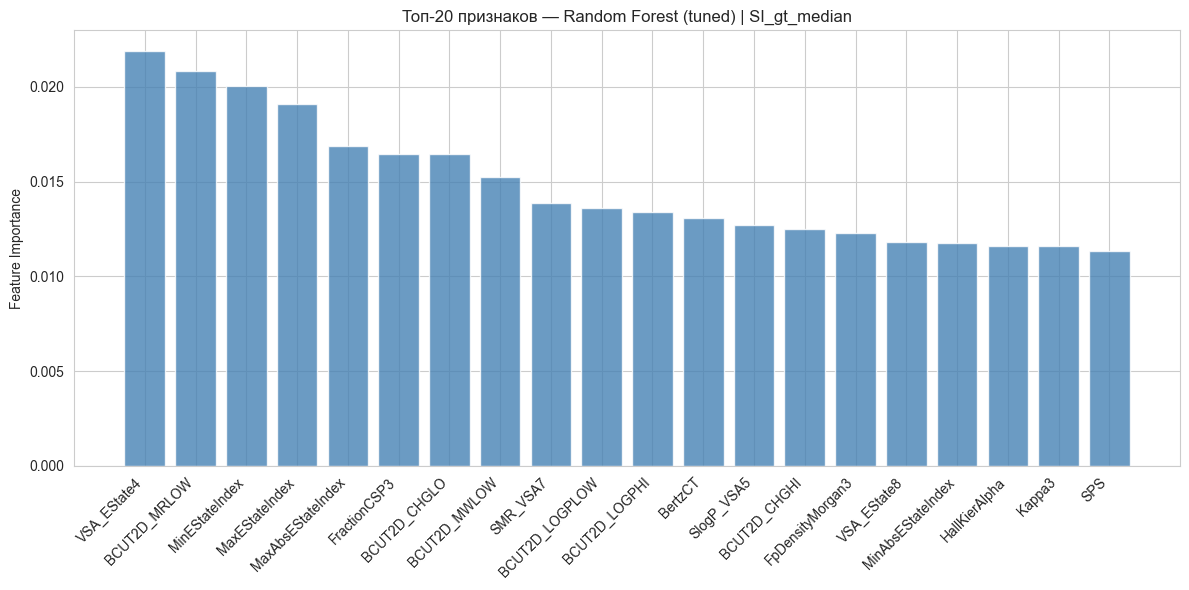

In [10]:
best_model.fit(X, y)

vt = best_model.named_steps['var_thresh']
selected_features = np.array(FEATURE_COLS)[vt.get_support()]

try:
    importances = best_model.named_steps['model'].feature_importances_
    top_idx = np.argsort(importances)[::-1][:20]

    plt.figure(figsize=(12, 6))
    plt.bar(range(20), importances[top_idx], color='steelblue', alpha=0.8)
    plt.xticks(range(20), selected_features[top_idx], rotation=45, ha='right')
    plt.title(f'Топ-20 признаков — {best_name} | {TASK_NAME}')
    plt.ylabel('Feature Importance')
    plt.tight_layout()
    plt.savefig(f'{TASK_NAME}_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
except AttributeError:
    # Logistic Regression: используем коэффициенты
    coefs = np.abs(best_model.named_steps['model'].coef_[0])
    top_idx = np.argsort(coefs)[::-1][:20]
    plt.figure(figsize=(12, 6))
    plt.bar(range(20), coefs[top_idx], color='steelblue', alpha=0.8)
    plt.xticks(range(20), selected_features[top_idx], rotation=45, ha='right')
    plt.title(f'Топ-20 признаков (|коэф|) — {best_name}')
    plt.tight_layout()
    plt.show()

## 7. Выводы

- Задача бинарной классификации решена для порога SI > медианы.
- Сравнено несколько классов классификаторов: логистическая регрессия, kNN, наивный байес, SVM, ансамблевые методы.
- Подобраны гиперпараметры для трёх лучших моделей через GridSearchCV и RandomizedSearchCV.
- Основная метрика — ROC-AUC (устойчива к дисбалансу классов).
- Для улучшения: можно применить SMOTE при дисбалансе, добавить Stacking, провести SHAP-анализ.